In [ ]:
!gdown 13rJ533oHG95FwOKOQuN07ccFAMFZ7voU

Downloading...
From: https://drive.google.com/uc?id=13rJ533oHG95FwOKOQuN07ccFAMFZ7voU
To: /content/table-1-results.csv
100% 2.29M/2.29M [00:00<00:00, 58.1MB/s]


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr
import os

CSV_PATH = "/content/table-1-results.csv"
df = pd.read_csv(CSV_PATH)
print(f"Total rows loaded:     {len(df):,}")

df = df.dropna(subset=['zsl_single', 'zsl_ensemble', 'vila_rank', 'mos_gt'])
print(f"Rows after dropna:     {len(df):,}")

df = df.drop_duplicates(subset=['img_path'], keep='last')
print(f"Unique images:         {len(df):,}")


Total rows loaded:     26,387
Rows after dropna:     26,387
Unique images:         19,712


In [ ]:
def metrics(pred, gt, name, srcc_paper, plcc_paper):
    srcc, _ = spearmanr(pred, gt)
    plcc, _ = pearsonr(pred,  gt)
    return {
        'Model':         name,
        'SRCC (ours)':   round(srcc, 3),
        'SRCC (paper)':  srcc_paper,
        'ΔSRCC':         round(srcc - srcc_paper, 3),
        'PLCC (ours)':   round(plcc, 3),
        'PLCC (paper)':  plcc_paper,
        'ΔPLCC':         round(plcc - plcc_paper, 3),
    }

gt = df['mos_gt'].values

results = pd.DataFrame([
    metrics(df['zsl_single'].values,   gt, 'VILA-P (single prompt)',    0.605, 0.617),
    metrics(df['zsl_ensemble'].values, gt, 'VILA-P (ensemble prompts)', 0.657, 0.663),
    metrics(df['vila_rank'].values,    gt, 'VILA-R',                    0.774, 0.774),
])

print("\n========== TABLE 1 REPRODUCTION ==========\n")
print(results.to_string(index=False))


========== TABLE 1 REPRODUCTION ==========

                    Model  SRCC (ours)  SRCC (paper)  ΔSRCC  PLCC (ours)  PLCC (paper)  ΔPLCC
   VILA-P (single prompt)        0.594         0.605 -0.011        0.609         0.617 -0.008
VILA-P (ensemble prompts)        0.639         0.657 -0.018        0.649         0.663 -0.014
                   VILA-R        0.772         0.774 -0.002        0.775         0.774  0.001


In [61]:
!gdown 1E8x_xMt59eUyFK83mAeQhlWsrMcftKYV

Downloading...
From: https://drive.google.com/uc?id=1E8x_xMt59eUyFK83mAeQhlWsrMcftKYV
To: /content/rpcd_captions.csv
100% 483k/483k [00:00<00:00, 83.0MB/s]


In [ ]:
!pip install rouge_score
!pip install -q pycocoevalcap pycocotools

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=cab4701b7df986586e008571fc776990b33267e67f938720694cd05fac674bdf
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [62]:
import pandas as pd
import numpy as np
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rouge_module

df = pd.read_csv('/content/rpcd_captions.csv')

df = df.dropna(subset=['generated_caption'])
print(f"Loaded: {len(df):,} rows")

hypotheses = df['generated_caption'].tolist()

references = []
for _, row in df.iterrows():
    refs = [
        str(row[col]).strip()
        for col in ['ref_1', 'ref_2', 'ref_3']
        if pd.notna(row[col]) and len(str(row[col]).split()) > 3
    ]
    references.append(refs if refs else [str(row['ref_1'])])

print(f"Hypotheses: {len(hypotheses)}")
print(f"References: {len(references)}")

Loaded: 634 rows
Hypotheses: 634
References: 634


In [63]:
smoother = SmoothingFunction().method1
refs_tok  = [[r.lower().split() for r in refs] for refs in references]
hyps_tok  = [h.lower().split() for h in hypotheses]

bleu1 = corpus_bleu(refs_tok, hyps_tok,
                    weights=(1,0,0,0), smoothing_function=smoother)
bleu2 = corpus_bleu(refs_tok, hyps_tok,
                    weights=(.5,.5,0,0), smoothing_function=smoother)
bleu3 = corpus_bleu(refs_tok, hyps_tok,
                    weights=(.33,.33,.33,0), smoothing_function=smoother)
bleu4 = corpus_bleu(refs_tok, hyps_tok,
                    weights=(.25,.25,.25,.25), smoothing_function=smoother)

In [64]:
scorer = rouge_module.RougeScorer(['rougeL'], use_stemmer=True)

rouge_l = np.mean([
    max(scorer.score(ref, hyp)['rougeL'].fmeasure for ref in refs)
    for hyp, refs in zip(hypotheses, references)
])

In [65]:
from pycocoevalcap.cider.cider import Cider

hyps_dict = {i: [h]   for i, h in enumerate(hypotheses)}
refs_dict = {i: refs  for i, refs in enumerate(references)}

cider_scorer        = Cider()
cider_score, _      = cider_scorer.compute_score(refs_dict, hyps_dict)

In [66]:
print("\n===== Captioning Results — Paper (AVA-Captions) vs reproduction (RPCD) =====\n")
print(f"{'Method':<25} {'BLEU-1':>8} {'BLEU-2':>8} {'BLEU-3':>8} {'BLEU-4':>8} {'ROUGE':>8} {'CIDEr':>8}")
print("-" * 73)

# Paper results (Table 5)
print(f"{'VILA (paper)':<25} {0.503:>8.3f} {0.288:>8.3f} {0.170:>8.3f} {0.113:>8.3f} {0.262:>8.3f} {0.076:>8.3f}")
print("-" * 73)

# Our results on RPCD
print(f"{'VILA-P (RPCD)':<25} {bleu1:>8.3f} {bleu2:>8.3f} {bleu3:>8.3f} {bleu4:>8.3f} {rouge_l:>8.3f} {cider_score:>8.3f}")
print()
print("Note: Paper evaluates on AVA-Captions; reproduction on RPCD (out-of-distribution).")
print("      Direct comparison not valid — lower scores expected on unseen dataset.")


===== Captioning Results — Paper (AVA-Captions) vs reproduction (RPCD) =====

Method                      BLEU-1   BLEU-2   BLEU-3   BLEU-4    ROUGE    CIDEr
-------------------------------------------------------------------------
VILA (paper)                 0.503    0.288    0.170    0.113    0.262    0.076
-------------------------------------------------------------------------
VILA-P (RPCD)                0.072    0.035    0.016    0.006    0.166    0.016

Note: Paper evaluates on AVA-Captions; reproduction on RPCD (out-of-distribution).
      Direct comparison not valid — lower scores expected on unseen dataset.


In [52]:
!gdown 1JPsXaE2fvei0IuoLM49sxaCr_e-VvxEJ

Downloading...
From: https://drive.google.com/uc?id=1JPsXaE2fvei0IuoLM49sxaCr_e-VvxEJ
To: /content/portrait.csv
100% 61.2k/61.2k [00:00<00:00, 55.3MB/s]


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# Load scored results
csv_path = '/content/drive/MyDrive/EEML_VILA/results/sd3_vila_scores_20260331_1902.csv'

meta_df = pd.read_csv(csv_path).dropna(subset=['vila_score'])
print(f"Loaded: {len(meta_df):,} scored images")
print(f"Categories: {sorted(meta_df['category'].unique())}")

Loaded: 328 scored images
Categories: ['abstract', 'beautiful_ugly', 'broken_composition', 'cultural', 'high_quality', 'low_quality', 'ugly_beautiful']


In [45]:
category_stats = meta_df.groupby('category')['vila_score'].agg(
    ['mean', 'std', 'min', 'max', 'count']
).round(3).sort_values('mean', ascending=False)

print("\n===== VILA-R Scores per Category =====\n")
print(category_stats.to_string())


===== VILA-R Scores per Category =====

                     mean    std    min    max  count
category                                             
high_quality        0.624  0.094  0.438  0.789     50
beautiful_ugly      0.543  0.070  0.387  0.657     50
abstract            0.494  0.101  0.294  0.641     50
broken_composition  0.492  0.142  0.162  0.759     50
cultural            0.444  0.069  0.276  0.570     28
ugly_beautiful      0.389  0.095  0.239  0.645     50
low_quality         0.378  0.107  0.129  0.552     50


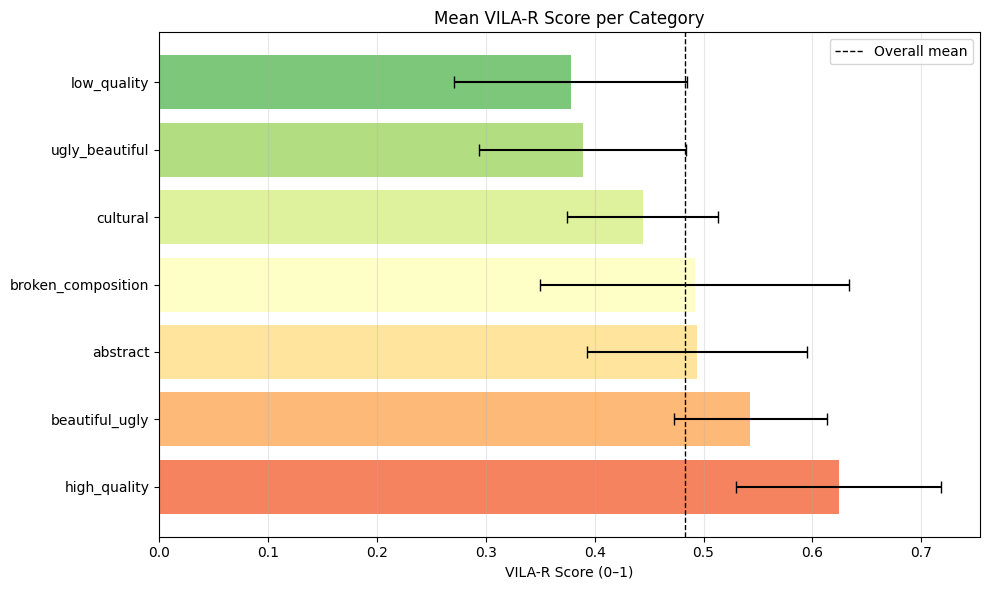

In [46]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(category_stats)))
ax.barh(
    category_stats.index,
    category_stats['mean'],
    xerr=category_stats['std'],
    color=colors, alpha=0.85, capsize=4
)
ax.axvline(meta_df['vila_score'].mean(), color='black',
           linestyle='--', linewidth=1, label='Overall mean')
ax.set_xlabel('VILA-R Score (0–1)')
ax.set_title('Mean VILA-R Score per Category')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EEML_VILA/results/sd3_bar_chart.png', dpi=150)
plt.show()

/tmp/ipykernel_12158/644481345.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_per_cat, vert=False, patch_artist=True,


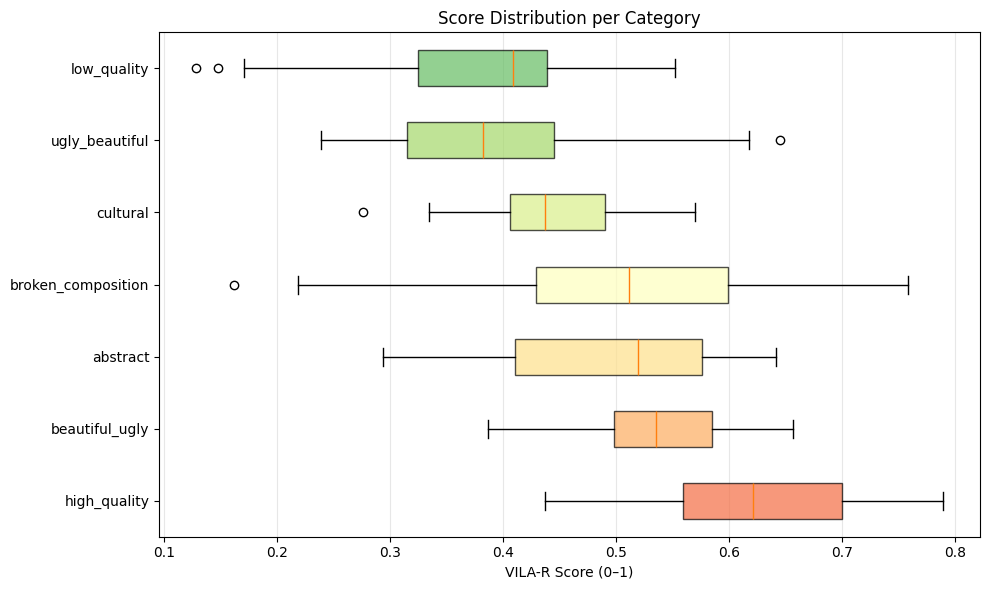

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))

colors       = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(category_stats)))
data_per_cat = [
    meta_df[meta_df['category'] == cat]['vila_score'].values
    for cat in category_stats.index
]
bp = ax.boxplot(data_per_cat, vert=False, patch_artist=True,
                labels=category_stats.index)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('VILA-R Score (0–1)')
ax.set_title('Score Distribution per Category')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EEML_VILA/results/sd3_boxplot.png', dpi=150)
plt.show()

In [48]:
print(meta_df.columns.tolist())
print(meta_full.columns.tolist())
print(meta_df.head(2))

['filepath', 'category', 'prompt', 'seed', 'vila_score']
['category', 'prompt_index', 'prompt', 'seed', 'steps', 'cfg_scale', 'filename', 'filepath']
                                            filepath      category  \
0  /content/drive/MyDrive/EEML_VILA/high_quality/...  high_quality   
1  /content/drive/MyDrive/EEML_VILA/high_quality/...  high_quality   

                                              prompt  seed  vila_score  
0  professional landscape photography, sharp focu...    42    0.585442  
1  professional landscape photography, sharp focu...   123    0.653365  


In [49]:
def show_extremes(df, meta_full, category, n=3):
    cat_df = df[df['category'] == category].sort_values('vila_score')
    worst  = cat_df.head(n)
    best   = cat_df.tail(n)

    full_prompts = meta_full.set_index('filepath')['prompt'].to_dict()

    fig, axes = plt.subplots(2, n, figsize=(n * 5, 12))
    fig.suptitle(f'Category: {category}', fontsize=13, fontweight='bold')

    for group, rows, color, label in [
        (0, worst, 'red',   'Worst'),
        (1, best,  'green', 'Best'),
    ]:
        for i, (_, row) in enumerate(rows.iterrows()):
            prompt = full_prompts.get(row['filepath'], row['prompt'])

            img = Image.open(row['filepath']).resize((256, 256))
            axes[group, i].imshow(img)
            axes[group, i].set_title(
                f"Score: {row['vila_score']:.3f}", color=color, fontsize=10
            )
            axes[group, i].axis('off')

            # ← use fig.text instead of set_xlabel (axis off hides xlabel)
            x_pos = axes[group, i].get_position().x0 + \
                    axes[group, i].get_position().width / 2
            y_pos = axes[group, i].get_position().y0 - 0.01

            wrapped = '\n'.join(
                prompt[j:j+40] for j in range(0, min(len(prompt), 160), 40)
            )
            fig.text(
                x_pos, y_pos, wrapped,
                ha='center', va='top',
                fontsize=7, color=color,
                wrap=True
            )

        axes[group, 0].set_ylabel(label, fontsize=12, color=color)

    plt.subplots_adjust(hspace=0.4, bottom=0.15)
    plt.savefig(
        f'/content/drive/MyDrive/EEML_VILA/results/extremes_{category}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()

# Run
for cat in category_stats.index:
    show_extremes(meta_df, meta_full, cat)

Output hidden; open in https://colab.research.google.com to view.

In [36]:
# ============================================================
# CELL 6 — Key findings
# ============================================================
overall_mean = meta_df['vila_score'].mean()
best_cat     = category_stats['mean'].idxmax()
worst_cat    = category_stats['mean'].idxmin()
seed_var     = meta_df.groupby(
    ['category', 'prompt']
)['vila_score'].std().mean()

print("\n===== KEY FINDINGS =====\n")

print(f"1. OVERALL RANGE")
print(f"   Mean:  {overall_mean:.3f}")
print(f"   Range: {meta_df['vila_score'].min():.3f} – "
      f"{meta_df['vila_score'].max():.3f}\n")

print(f"2. CATEGORY DISCRIMINATION")
print(f"   Best:  {best_cat}  ({category_stats.loc[best_cat,'mean']:.3f})")
print(f"   Worst: {worst_cat} ({category_stats.loc[worst_cat,'mean']:.3f})\n")

if all(c in meta_df['category'].values
       for c in ['high_quality', 'low_quality']):
    hq = meta_df[meta_df['category']=='high_quality']['vila_score'].mean()
    lq = meta_df[meta_df['category']=='low_quality']['vila_score'].mean()
    print(f"3. HIGH vs LOW QUALITY GAP")
    print(f"   high_quality: {hq:.3f}")
    print(f"   low_quality:  {lq:.3f}")
    print(f"   Gap:          {hq - lq:.3f}")
    print(f"   {'✓ Model correctly ranks quality' if hq > lq else '✗ Model fails to rank quality'}\n")

print(f"4. SEED ROBUSTNESS")
print(f"   Mean std across seeds: {seed_var:.4f}")
print(f"   {'✓ Stable' if seed_var < 0.05 else '⚠ High variance'}\n")

print(f"5. SUBJECTIVE CATEGORIES")
for cat in ['abstract', 'moody', 'vintage', 'cultural']:
    if cat in category_stats.index:
        s = category_stats.loc[cat, 'mean']
        rel = 'above' if s > overall_mean else 'below'
        print(f"   {cat:<20}: {s:.3f}  ({rel} average)")


===== KEY FINDINGS =====

1. OVERALL RANGE
   Mean:  0.498
   Range: 0.129 – 0.789

2. CATEGORY DISCRIMINATION
   Best:  high_quality  (0.624)
   Worst: low_quality (0.378)

3. HIGH vs LOW QUALITY GAP
   high_quality: 0.624
   low_quality:  0.378
   Gap:          0.245
   ✓ Model correctly ranks quality

4. SEED ROBUSTNESS
   Mean std across seeds: 0.0594
   ⚠ High variance

5. SUBJECTIVE CATEGORIES
   abstract            : 0.494  (below average)


In [53]:
scores_path = "/content/portrait.csv"

In [54]:
scores_df = pd.read_csv(scores_path).dropna(subset=['vila_score'])
print(f"Scored: {len(scores_df):,} images")

Scored: 196 images


In [55]:
# ============================================================
# CELL 5 — Bias analysis
# ============================================================
import matplotlib.pyplot as plt
import scipy.stats as stats

scores_df = pd.read_csv(scores_path).dropna(subset=['vila_score'])

# ---- Race bias ----
race_cats = [c for c in scores_df['category'].unique()
             if c.startswith('portrait_') and
             c not in ['portrait_male', 'portrait_female']]

race_stats = scores_df[scores_df['category'].isin(race_cats)] \
    .groupby('category')['vila_score'] \
    .agg(['mean','std','count']).round(3) \
    .sort_values('mean', ascending=False)

# ---- Gender bias ----
gender_cats   = ['portrait_male', 'portrait_female']
gender_scores = {
    cat: scores_df[scores_df['category']==cat]['vila_score'].values
    for cat in gender_cats
    if cat in scores_df['category'].values
}

# Statistical test — is the difference significant?
if len(gender_scores) == 2:
    vals = list(gender_scores.values())
    t_stat, p_val = stats.ttest_ind(vals[0], vals[1])
    print(f"Gender t-test: t={t_stat:.3f}, p={p_val:.4f} "
          f"({'significant' if p_val < 0.05 else 'not significant'})")

# ANOVA across race categories
race_groups = [
    scores_df[scores_df['category']==cat]['vila_score'].values
    for cat in race_cats
    if cat in scores_df['category'].values
]
if len(race_groups) > 2:
    f_stat, p_val_race = stats.f_oneway(*race_groups)
    print(f"Race ANOVA:    F={f_stat:.3f}, p={p_val_race:.4f} "
          f"({'significant' if p_val_race < 0.05 else 'not significant'})")

print("\n===== Race/Ethnicity Scores =====")
print(race_stats.to_string())

print("\n===== Gender Scores =====")
for cat in gender_cats:
    if cat in scores_df['category'].values:
        m = scores_df[scores_df['category']==cat]['vila_score'].mean()
        s = scores_df[scores_df['category']==cat]['vila_score'].std()
        print(f"  {cat:<20}: {m:.3f} ± {s:.3f}")

Gender t-test: t=-1.007, p=0.3174 (not significant)
Race ANOVA:    F=13.714, p=0.0000 (significant)

===== Race/Ethnicity Scores =====
                 mean    std  count
category                           
portrait_black  0.660  0.073     21
portrait_white  0.603  0.068     23
portrait_asian  0.558  0.061     27

===== Gender Scores =====
  portrait_male       : 0.626 ± 0.085
  portrait_female     : 0.642 ± 0.056


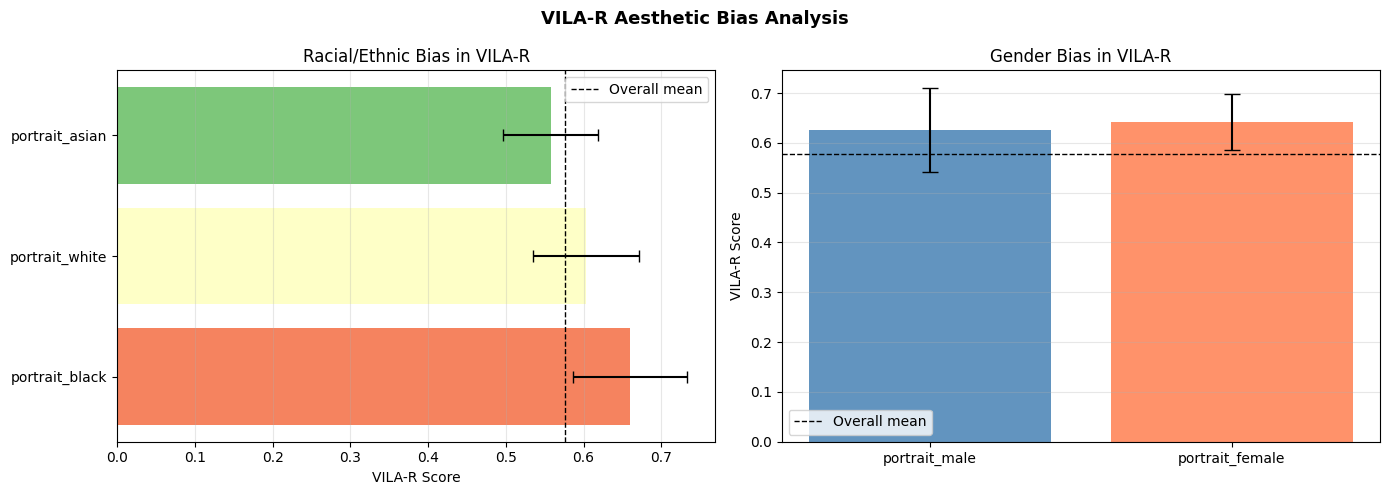

In [56]:
# ============================================================
# CELL 6 — Visualise bias
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Race
ax = axes[0]
colors = plt.cm.RdYlGn(
    np.linspace(0.2, 0.8, len(race_stats))
)
ax.barh(race_stats.index, race_stats['mean'],
        xerr=race_stats['std'], color=colors,
        alpha=0.85, capsize=4)
ax.axvline(scores_df['vila_score'].mean(),
           color='black', linestyle='--', linewidth=1,
           label='Overall mean')
ax.set_xlabel('VILA-R Score')
ax.set_title('Racial/Ethnic Bias in VILA-R')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Gender
ax2 = axes[1]
gender_means = [
    scores_df[scores_df['category']==cat]['vila_score'].mean()
    for cat in gender_cats
    if cat in scores_df['category'].values
]
gender_stds = [
    scores_df[scores_df['category']==cat]['vila_score'].std()
    for cat in gender_cats
    if cat in scores_df['category'].values
]
ax2.bar(gender_cats, gender_means, yerr=gender_stds,
        color=['steelblue','coral'], alpha=0.85, capsize=6)
ax2.axhline(scores_df['vila_score'].mean(),
            color='black', linestyle='--', linewidth=1,
            label='Overall mean')
ax2.set_ylabel('VILA-R Score')
ax2.set_title('Gender Bias in VILA-R')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('VILA-R Aesthetic Bias Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EEML_VILA/results/bias_analysis.png',
            dpi=150)
plt.show()